# Character animation
This notebook is a basic example of how to use Kling 2.1 model to create videos based on their initial and final state.

Let's import the necessary libraries:

In [1]:
import base64
import fal_client
import os
import requests

import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
from io import BytesIO
from IPython.display import Video
from PIL import Image

load_dotenv("../../../_starter/.env")

True

### Start by setting up a client

In [2]:
client = fal_client

## Helper functions

In [3]:
def on_queue_update(update):
    if isinstance(update, fal_client.InProgress):
        for log in update.logs:
           print(log["message"])

def process_video_request(prompt, image_url, tail_image_url, negative_prompt, duration=5, cfg_scale=0.5):
    """
    Process a video request using the Kling 2.1 model.

    Args:
        prompt (str): The prompt for the video generation.
        image_url (str): The URL of the initial image.
        tail_image_url (str): The URL of the final image.
        negative_prompt (str): The negative prompt for the video generation.
        duration (int): The duration of the video in seconds.
        cfg_scale (float): The CFG scale for the video generation.

    Returns:
        result (dict): The result of the video generation.  
    """
    result = fal_client.subscribe(
        "fal-ai/kling-video/v2.1/pro/image-to-video",
        arguments={
            "prompt": prompt,
            "image_url": image_url,
            "tail_image_url": tail_image_url,
            "duration": duration,
            "negative_prompt": negative_prompt,
            "cfg_scale": cfg_scale
        },
        with_logs=True,
        on_queue_update=on_queue_update,
    )
    return result

## Idle position

This will be out neutral transition state between different animation phases.

Each animation should start or end with in this pose.

To do so we will pass this image either as first or last frame of the generated video.

https://v3.fal.media/files/koala/acFbXC_x3AF2_rT2LaqkN_portrait_teodor_talowski_studio.png


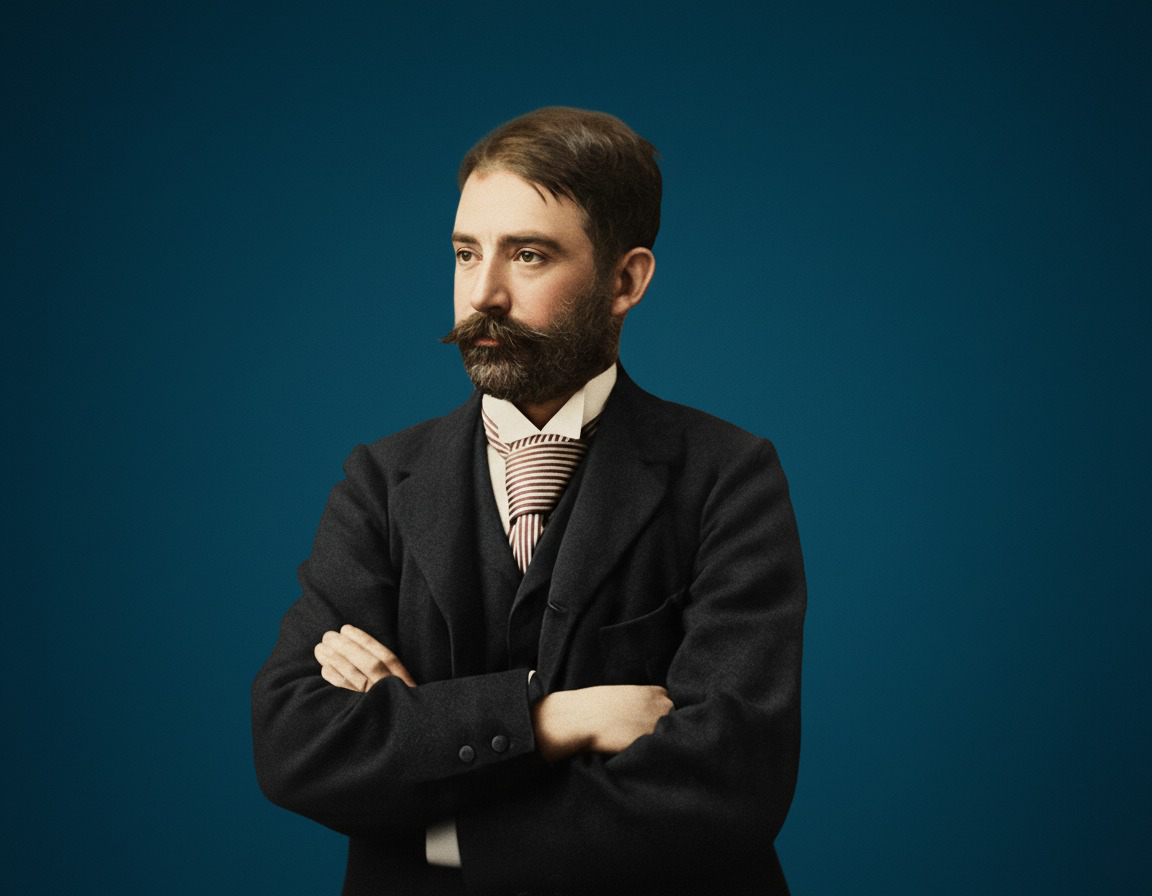

In [4]:
idle_position_file_name = "../../assets/portrait_teodor_talowski_studio.png"

# Load image
idle_position_image = Image.open(idle_position_file_name)

# Upload and get the URL of the image
idle_position_url = fal_client.upload_file(idle_position_file_name)

print(idle_position_url)
idle_position_image

## Clean plate

Lets generate the background image without the person so we can make sure that each animation of a person leaving the frame ends with the same background.

https://v3.fal.media/files/panda/udiHbpKo9IMJtteZF9WmB_clean_plate.png


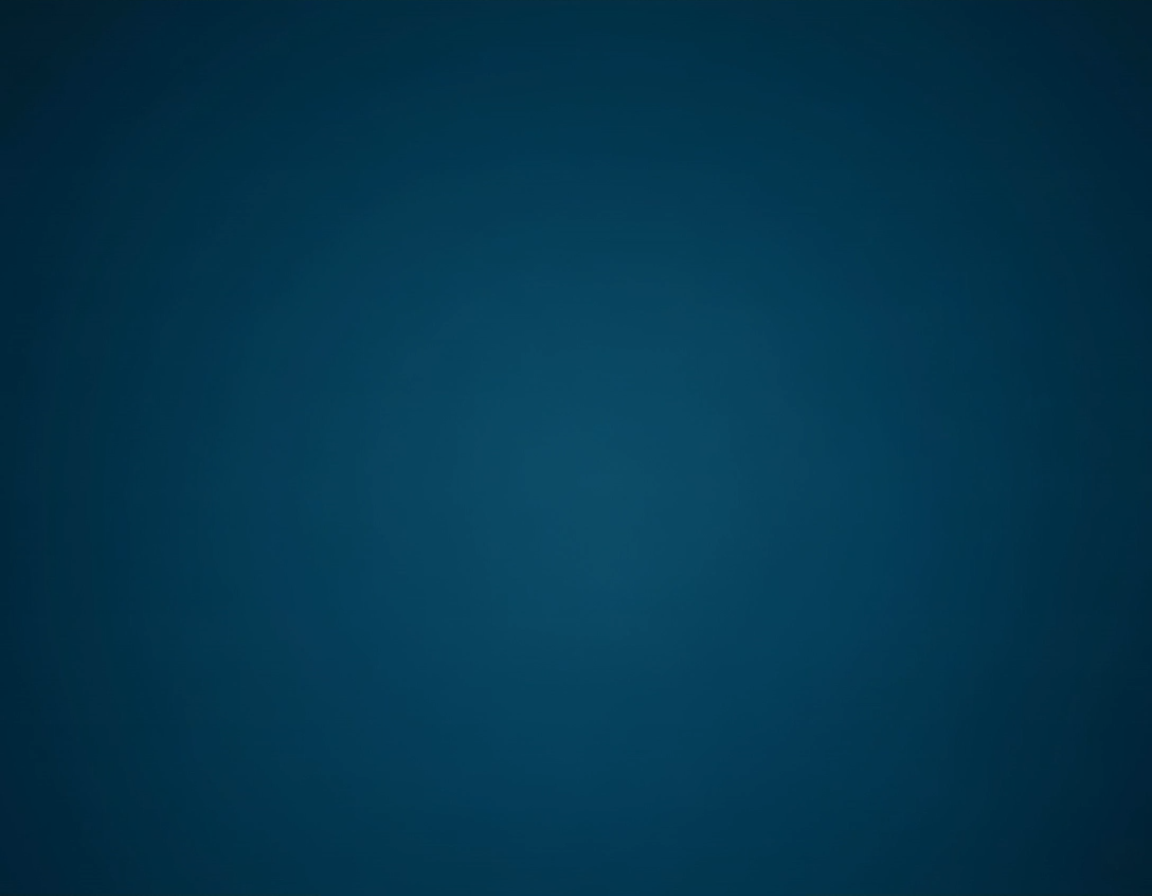

In [5]:
clean_plate_file_name = "../../assets/clean_plate.png"

# Load image
clean_plate_image = Image.open(clean_plate_file_name)

# Upload and get the URL of the image
clean_plate_url = fal_client.upload_file(clean_plate_file_name)

print(clean_plate_url)
clean_plate_image

## Negative prompt

In [6]:
negative_prompt = "blur, distort, and low quality"

## Person leaving the frame

Available methods:

1. In first method we can just ask the model to generate a video of the person leaving the frame.

2. Other method would be to use the clean plate of the background without the person as the last frame of the video.

First method can cause some issues with the background, so we will use the second method instead.

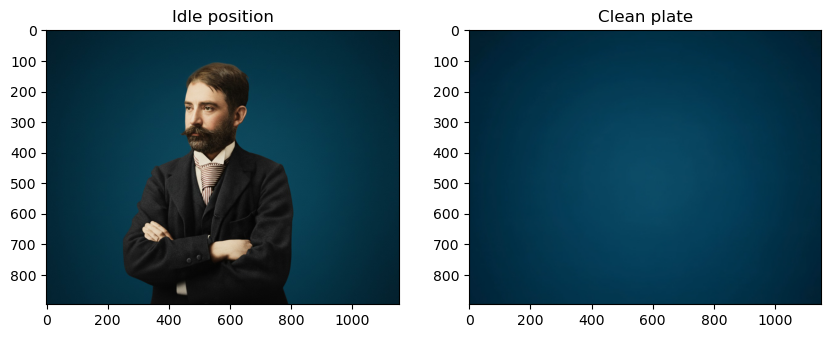

In [7]:
# Show images side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(idle_position_image)
axs[1].imshow(clean_plate_image)
axs[0].set_title("Idle position")
axs[1].set_title("Clean plate")
plt.show()

Notice that we will use a video model to generate frames between the idle position and the clean plate.

To make sure model understands our task we will need to specify few things in the prompt:
1. Action - person leaving the frame
2. Direction - person is leaving the frame on the left side
3. Camera - lets make sure to specify that camera is static and on the tripod

Example prompt could look like this:

"A person is leaving the frame on the left side, camera is static and on the tripod"

Let's try it out!

In [8]:
results = process_video_request(
    prompt="A person is leaving the frame on the left side, camera is static and on the tripod",
    image_url=idle_position_url,
    tail_image_url=clean_plate_url,
    negative_prompt=negative_prompt,
    duration=5,
    cfg_scale=0.5
)

person_leaving_url = results["video"]['url']

response = requests.get(person_leaving_url)
with open("../../outputs/1_person_leaving_left.mp4", "wb") as f:
    f.write(response.content)

Video("../../outputs/1_person_leaving_left.mp4")

## Person coming back into the frame

Let's create and video where the person is coming back into the frame.

We will use the same method as before, but this time we will use the idle position as the first frame and the person as the last frame.

Let's start by creating the prompt:

"A person is coming back into the frame from the right side, camera is static and on the tripod"

In [9]:
results = process_video_request(
    prompt="A person is coming back into the frame from the right side, camera is static and on the tripod",
    image_url=clean_plate_url,
    tail_image_url=idle_position_url,
    negative_prompt=negative_prompt,
    duration=5,
    cfg_scale=0.5
)

person_leaving_url = results["video"]['url']

response = requests.get(person_leaving_url)
with open("../../outputs/2_person_coming_back_right.mp4", "wb") as f:
    f.write(response.content)

Video("../../outputs/2_person_coming_back_right.mp4")

## Adding idle animation

To make person perform an action in the middle of the frame and come back to the idle position we can use the following prompt:

"A person is smiling and waving at the camera, then comes back into the same position"

This time we will use the idle position as both the first and last frame of the video.


In [10]:
results = process_video_request(
    prompt="A person is smiling and waving at the camera, then comes back into the same position",
    image_url=idle_position_url,
    tail_image_url=idle_position_url,
    negative_prompt=negative_prompt,
    duration=5,
    cfg_scale=0.5
)

person_leaving_url = results["video"]['url']

response = requests.get(person_leaving_url)
with open("../../outputs/3_person_waving_idle.mp4", "wb") as f:
    f.write(response.content)

Video("../../outputs/3_person_waving_idle.mp4")